## Multi-Layer Perceptron Learning in Tensorflow


Multi-Layer Perceptron (MLP) consists of fully connected dense layers that transform input data from one dimension to another. It is called multi-layer because it contains an input layer, one or more hidden layers and an output layer. The purpose of an MLP is to model complex relationships between inputs and outputs.

## Components of Multi-Layer Perceptron (MLP)

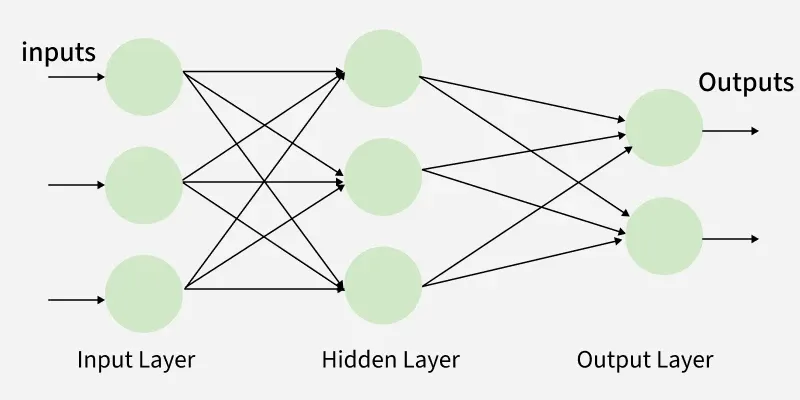

* **Input Layer:** Each neuron or node in this layer corresponds to an input feature. For instance, if you have three input features the input layer will have three neurons.
* **Hidden Layers:** MLP can have any number of hidden layers with each layer containing any number of nodes. These layers process the information received from the input layer.
* **Output Layer:** The output layer generates the final prediction or result. If there are multiple outputs, the output layer will have a corresponding number of neurons.

## Working of Multi-Layer Perceptron

1. **Forward Propagation:** The input data is passed through the network layer by layer. Each layer applies a linear transformation followed by a non-linear activation function to the data.
2. **Loss Calculation:** The output from the final layer is compared to the actual target values to calculate the loss using a loss function.
3. **Backpropagation:** The loss is propagated back through the network to update the weights and biases of the neurons using an optimization algorithm like Adam or Stochastic Gradient Descent (SGD).
4. **Iteration:** This process is repeated for multiple iterations (epochs) until the model converges to a solution that minimizes the loss.
5. **Optimization:** The weights and biases are updated in a way that minimizes the loss function, allowing the model to learn from the data and improve its predictions over time.


## Implementing Multi Layer Perceptron

In this section, we will guide through building a neural network using TensorFlow.

### 1. Importing Modules and Loading Dataset

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

## 2. Loading and Normalizing Image Data

In [2]:
gray_scale = 255

x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


## 3. Visualizing Data

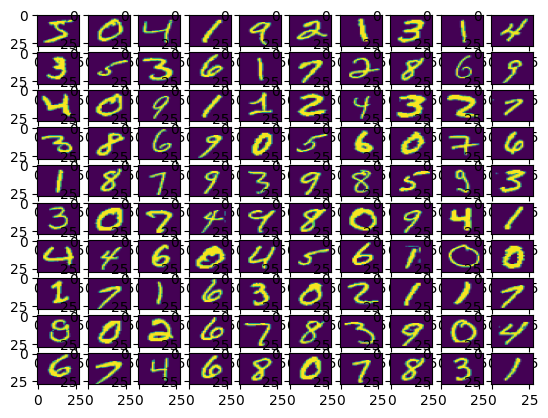

In [3]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

## 4. Building the Neural Network Model

In [4]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='sigmoid'),  
    Dense(128, activation='sigmoid'), 
    Dense(10, activation='softmax'),  
])

C:\Users\PANDIT JI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 5. Compiling the Model

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 6. Training the Model

In [6]:
mod = model.fit(x_train, y_train, epochs=10, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3527 - loss: 2.1161 - val_accuracy: 0.6462 - val_loss: 1.7934
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7141 - loss: 1.4689 - val_accuracy: 0.7882 - val_loss: 1.1091
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8087 - loss: 0.9267 - val_accuracy: 0.8580 - val_loss: 0.7186
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8587 - loss: 0.6445 - val_accuracy: 0.8850 - val_loss: 0.5242
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8832 - loss: 0.4972 - val_accuracy: 0.8969 - val_loss: 0.4221
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8958 - loss: 0.4155 - val_accuracy: 0.9067 - val_loss: 0.3655
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9046 - loss: 0.3656 - val_accuracy: 0.9134 - val_loss: 0.3281
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9115 - loss: 0.3313 - val_accuracy: 0.9178 - v

## 7. Evaluating the Model

In [7]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.27243494987487793, 0.92330002784729]


## 8. Visualizing Training and Validation Loss VS Accuracy

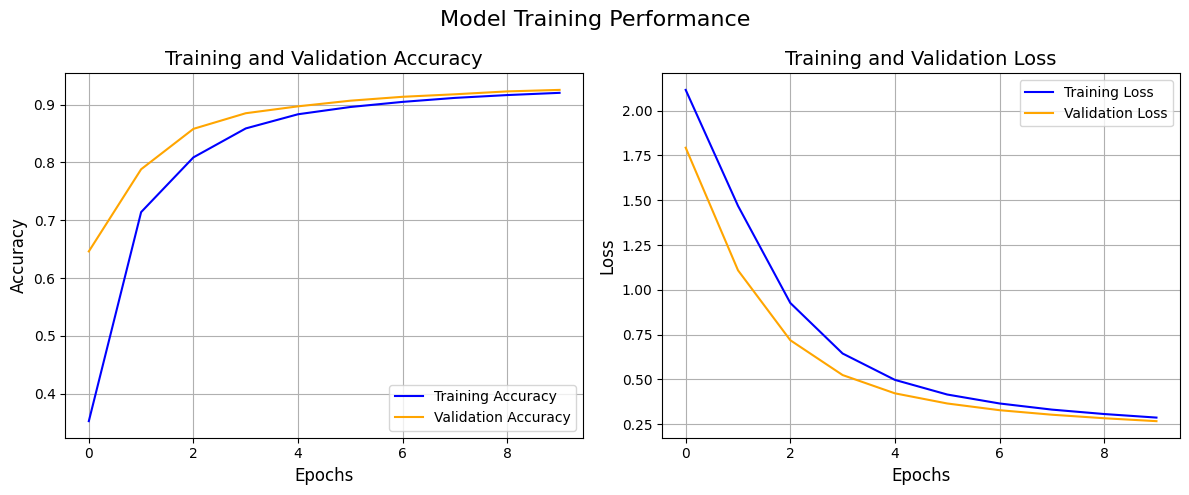

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()